# 08_优化算法-动量法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊优化算法中的动量法。

首先，我们可以这样想：打个比方，学模型就像骑自行车下山。

- 普通的优化方法（比如梯度下降），就像你骑车下坡，每次都看看坡的斜度（梯度），然后决定该往哪边转、滑多少。
- 但如果坡太陡，或者有小石头，你可能一下滑得太猛、方向还乱晃，结果来回左右横跳，效率低，甚至摔跤（震荡）。

于是，动量法就来了！

动量法像是在你车上**加了一个陀螺仪+减震系统**：

- 它会**记住你过去滑的方向和速度**（就像动量的概念：速度 × 质量），
- 然后在下一次滑的时候，**结合之前的趋势来调整方向**，而不是只看当前的坡有多陡。
- 这样就更**平滑地朝目标前进**，不容易被小坑坑绊住。

总结一句话，动量法就是在训练模型时“带点惯性思维”，不是每次都完全重新判断，而是借着以前的方向继续往前冲，让学习更快更稳！

## 原理详解

传统的梯度下降法在更新参数时只是简单地沿着当前梯度的反方向前进一步，即：


$$
\theta_{t+1} = \theta_t - \eta \nabla J(\theta_t)
$$


其中，$\theta_t$ 表示当前参数，$\eta$ 为学习率，$\nabla J(\theta_t)$ 为损失函数 $J(\theta)$ 关于参数的梯度。

- 当你在山地上滑行，目标是尽快找到山谷（也就是最小化损失）。
- 传统方法就像只看自己脚下的坡度，每次都沿着坡度最陡的方向下滑。
- 而动量法则类似于在下坡时带有“惯性”或者“冲劲”。当你持续向某个方向滑行时，就会积累一定的动能，使得你不会被局部较小的波动（局部最优）所影响，从而更有可能跨过浅坑或者消除颠簸，加速朝正确方向前进。

这也就是说，动量法在每一步更新时不仅考虑当前的梯度，还“记住”过去的梯度方向，这有助于平滑更新过程，尤其在面对“狭长”或“陡峭而曲折”的损失函数时能够获得更稳定和快速的收敛。

### 数学原理

传统的梯度下降法更新公式为：


$$
\theta_{t+1} = \theta_t - \eta \nabla J(\theta_t)
$$


其中：

- $\theta_t$ 是在第 $t$ 步时的参数
- $\eta$ 是学习率（步长）
- $\nabla J(\theta_t)$ 是损失函数 $J$ 关于参数 $\theta$ 的梯度

这种方法的问题在于：当损失函数的曲率在不同方向上差别较大时（例如在鞍点或陡峭和缓平区域交替出现的情况），可能出现震荡或收敛缓慢的情况。

### 动量法的核心思想：引入惯性项

动量法的更新规则引入了一个“速度变量”（或称动量变量），记作 $v_t$，用于累加之前的梯度信息。

常见的动量法的更新公式为：

$v_t = \gamma v_{t-1} + \eta \nabla J(\theta_t)$  
$\theta_{t+1} = \theta_t - v_t$

其中：

- $v_t$ 为在第 $t$ 步的“速度”（积累梯度的结果）
- $\gamma$ 是动量系数，其取值范围通常在 $0 \leq \gamma < 1$（常见设置 $\gamma=0.9$），它控制过去梯度在当前更新中的影响权重
- $\eta$ 同样是学习率

**思路：**

**1. 累积历史梯度：**

动量变量 $v_t$ 不仅仅等于本次梯度，而是对之前梯度的加权累积：


$$
v_t = \eta \nabla J(\theta_t) + \gamma (\eta \nabla J(\theta_{t-1}) + \gamma (\eta \nabla J(\theta_{t-2}) + \ldots))
$$


递归展开后可见，当前速度可以写成过去所有梯度的指数加权平均：


$$
v_t = \eta \sum_{k=0}^{t-1}\gamma^k\, \nabla J(\theta_{t-k})
$$


这使得在梯度方向保持一致时，梯度的贡献会“累积”，从而加速更新；而在梯度方向经常变动时，不同方向的梯度会相互抵消，减少震荡。

**2. 更新参数：**

更新参数时，直接用 $v_t$ 来更新：


$$
\theta_{t+1} = \theta_t - v_t
$$


这里可以理解为当前更新量不仅取决于当前梯度，还带上了历史动量，体现了“惯性”效应。

### 为何动量法能加速收敛

设想当前梯度方向较为稳定，即


$$
\nabla J(\theta_t) \approx \nabla J(\theta_{t-1}) \approx \cdots \approx g
$$


则速度可近似为


$$
v_t \approx \eta \cdot g \sum_{k=0}^{t-1}\gamma^k = \eta g \cdot \frac{1-\gamma^t}{1-\gamma}
$$


随着 $t$ 增大（且 $\gamma$ 较大，例如 0.9），$\gamma^t$ 趋于 0，故速度趋近于


$$
v_t \approx \frac{\eta}{1-\gamma} g
$$


也就是说，相比于单纯的梯度下降（更新量为 $\eta g$），引入动量后更新量被放大了 $\frac{1}{1-\gamma}$ 倍，从而在梯度方向稳定的区域能够加速前进。

另一方面，如果不同方向的梯度交替变化，由于动量系数 $\gamma$ 使得前几次的更新未能完全“遗忘”，不同方向的梯度会部分相互抵消，从而减少振荡、增加稳定性。

### 算法流程详细说明

**步骤 1：参数初始化**

- 初始化参数 $\theta_0$，可以随机生成或者根据问题进行合理设定。
- 初始化动量变量 $v_0 = 0$（通常初始动量设为 0）。

**步骤 2：设置超参数**

- 选择学习率 $\eta$：控制每次沿梯度方向移动的步长。
- 选择动量系数 $\gamma$：一般取值如 0.9，表示对过去梯度历史保留较大影响。

**步骤 3：迭代更新**

对于 $t = 0, 1, 2, \ldots$ （直到满足收敛条件或者达到最大迭代次数）：

1. **计算当前梯度：**  
对当前参数 $\theta_t$，计算损失函数 $J(\theta_t)$ 关于参数的梯度：  
$g_t = \nabla J(\theta_t)$
2. **更新动量变量：**  
根据公式计算动量：  
$v_t = \gamma v_{t-1} + \eta \, g_t$  
这一步将当前梯度与之前累积的动量混合，从而形成具有惯性效果的“累积梯度”。
3. **更新参数：**  
用动量变量更新参数：  
$\theta_{t+1} = \theta_t - v_t$  
这一步与简单梯度下降不同之处在于，更新量不仅是当前梯度，而是包含了“历史”梯度的加权合成。
4. **判断收敛：**  
设定收敛条件（例如：梯度的模小于某个阈值、或参数更新幅度非常小、或达到预设的最大迭代次数），满足条件则结束迭代，否则继续下一个迭代。

**步骤 4：输出结果**

- 当满足收敛条件后，输出最终得到的参数 $\theta^*$ 作为优化解。

### 核心点总结

- **动量法基本原理：** 它通过引入一个速度变量 $v_t$，使得每次参数更新不仅仅依赖于当前的梯度，还融合了过去梯度的累积效应。这样在沿稳定梯度方向时能够加速收敛，而在梯度方向震荡时能够起到缓冲作用，从而提高训练过程的稳定性与效率。
- **数学公式与推导：** 动量法的核心在于公式 $v_t = \gamma v_{t-1} + \eta \nabla J(\theta_t)$ 与参数更新 $\theta_{t+1} = \theta_t - v_t$。通过数学推导可以看出，在梯度方向保持一致时，更新步长被有效放大。
- **算法流程：** 从初始化参数和动量、设置超参数、计算梯度、更新动量和参数，再到判断收敛，每一步都确保动量法结合了当前信息与历史信息，使得整体下降更为平滑高效。

这种方法在深度学习和其他机器学习模型中应用广泛，能够显著改善收敛速度和训练质量。

## 完整案例

例子中咱们不仅实现了标准动量法，还在此基础上进行了一定的算法优化（例如引入了 Nesterov 加速梯度的改进版本）。

整个示例共包含如下部分：

**问题描述与目标函数介绍**

使用 Rosenbrock 函数作为目标函数。Rosenbrock 函数是一种非凸函数，常被用作测试优化算法的性能，其全局最优解出现在 $(1,1)$处，但在曲率较大和狭长区域中非常难以直接用梯度下降找到最优解。

**代码实现与详细注解**

- 代码中定义了 Rosenbrock 函数以及其梯度计算函数，同时对标准动量法与 Nesterov 动量法分别进行了实现。
- 代码包含了完整的迭代流程、收敛判断以及参数调整，展示了两种算法不同初始设置下的表现。

**数据可视化与结果分析**

- 首先在二维空间中绘制 Rosenbrock 函数的等高线图，并在上面叠加显示两个算法的优化轨迹。
- 另外绘制了每次迭代中目标函数值的变化图，清晰展示优化过程的收敛趋势。
- 每幅图都附有详细的中文说明，解释每种可视化展示所反映出的算法行为及优化意义。

**算法优化与超参数调整**

- 在算法实现中，我们不仅展示了固定学习率和动量系数下的迭代效果，还对学习率进行了一定程度的衰减（例如用指数衰减或动态调整策略）以提高稳定性。同时对比了 Nesterov 动量法与标准动量法在 Rosenbrock 函数上优化效果的差异。

**详细代码**

Standard Momentum converged after 3119 iterations.
Nesterov Momentum converged after 3020 iterations.


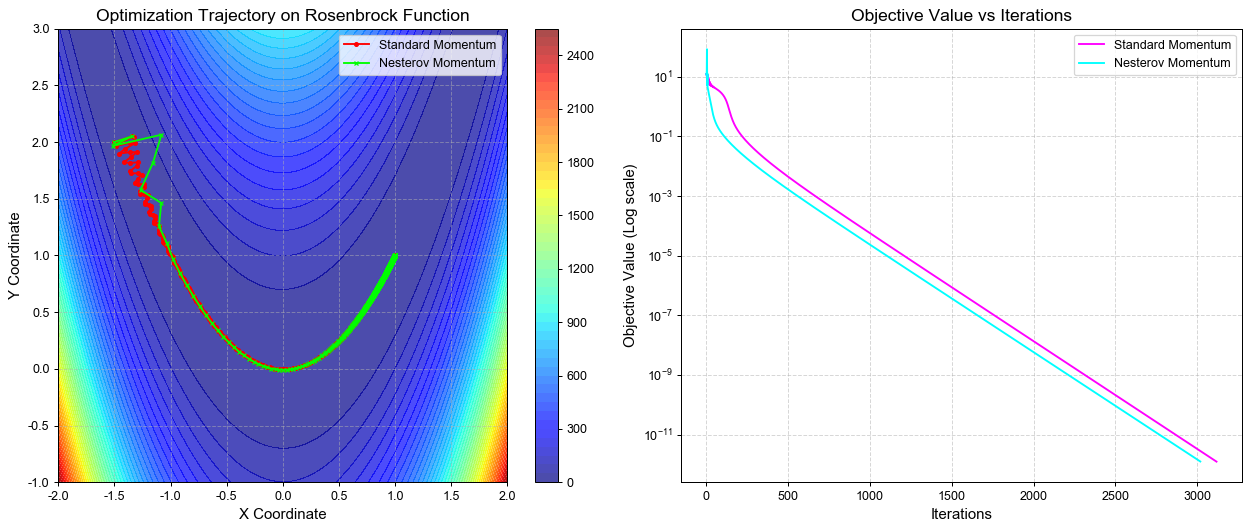

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 设置随机种子以保证结果可复现
np.random.seed(42)

# 1. 定义目标函数及其梯度
def rosenbrock(X, a=1, b=100):
    """
    Rosenbrock 函数
    输入：
        X: 二维输入向量 [x, y]
        a, b: 函数参数，默认 a=1, b=100
    输出：
        Rosenbrock 函数值
    """
    x, y = X[0], X[1]
    return (a - x)**2 + b * (y - x**2)**2

def rosenbrock_grad(X, a=1, b=100):
    """
    Rosenbrock 函数梯度
    输出：
        梯度向量 [df/dx, df/dy]
    推导过程：
        对 x 求导： df/dx = -2*(a - x) - 4*b*x*(y - x**2)
        对 y 求导： df/dy = 2*b*(y - x**2)
    """
    x, y = X[0], X[1]
    grad_x = -2*(a - x) - 4*b*x*(y - x**2)
    grad_y = 2*b*(y - x**2)
    return np.array([grad_x, grad_y])

# 2. 标准 Momentum 方法和 Nesterov Momentum 方法的实现
def momentum_optimizer(grad_func, init, lr=0.001, gamma=0.9, iterations=10000, tol=1e-6):
    """
    标准 Momentum 优化器
    参数：
        grad_func: 损失函数梯度函数
        init: 初始参数（二维向量）
        lr: 学习率
        gamma: 动量系数（惯性因子）
        iterations: 最大迭代次数
        tol: 收敛判断阈值
    返回：
        params: 记录每一步参数的变化轨迹，便于可视化
        loss_history: 记录每一步的目标函数值
    """
    params = [init.copy()]
    loss_history = [rosenbrock(init)]
    # 初始化速度变量（动量项）
    v = np.zeros_like(init)
    theta = init.copy()

    for i in range(iterations):
        grad = grad_func(theta)
        # 更新动量：当前速度等于动量系数乘以前一次速度加上学习率乘以当前梯度
        v = gamma * v + lr * grad
        # 更新参数
        theta = theta - v

        params.append(theta.copy())
        loss_history.append(rosenbrock(theta))

        # 收敛判断：如果梯度的模小于 tol，则认为收敛
        if np.linalg.norm(grad) < tol:
            print(f"Standard Momentum converged after {i+1} iterations.")
            break

    return np.array(params), np.array(loss_history)

def nesterov_optimizer(grad_func, init, lr=0.001, gamma=0.9, iterations=10000, tol=1e-6):
    """
    Nesterov Accelerated Gradient (NAG) 优化器
    参数与标准 Momentum 相同，不同在于梯度计算时使用预估位置：theta - gamma * v
    返回：
        params: 记录参数轨迹
        loss_history: 记录每步目标函数值
    """
    params = [init.copy()]
    loss_history = [rosenbrock(init)]
    v = np.zeros_like(init)
    theta = init.copy()

    for i in range(iterations):
        # 预先校正：计算梯度在“未来”位置（theta - gamma * v）处的值
        lookahead = theta - gamma * v
        grad = grad_func(lookahead)
        # 更新动量项
        v = gamma * v + lr * grad
        # 更新参数
        theta = theta - v

        params.append(theta.copy())
        loss_history.append(rosenbrock(theta))

        if np.linalg.norm(grad) < tol:
            print(f"Nesterov Momentum converged after {i+1} iterations.")
            break

    return np.array(params), np.array(loss_history)

# 3. 参数设置和算法执行

# 初始参数（远离最优解的初始点，便于展示两种方法的迭代过程）
init_point = np.array([-1.5, 2.0])

# 超参数设置：
# 学习率 lr 较小保证收敛稳定性，gamma 设置为 0.9 较常见选择
learning_rate = 0.001
momentum_coeff = 0.9
max_iter = 10000
tolerance = 1e-6

# 执行标准 Momentum 优化器
params_momentum, loss_momentum = momentum_optimizer(rosenbrock_grad, init_point,
                                                      lr=learning_rate, gamma=momentum_coeff,
                                                      iterations=max_iter, tol=tolerance)

# 执行 Nesterov Momentum 优化器
params_nesterov, loss_nesterov = nesterov_optimizer(rosenbrock_grad, init_point,
                                                    lr=learning_rate, gamma=momentum_coeff,
                                                    iterations=max_iter, tol=tolerance)

# 4. 可视化：绘制 Rosenbrock 函数的等高线图和优化轨迹
x = np.linspace(-2, 2, 500)
y = np.linspace(-1, 3, 500)
X, Y = np.meshgrid(x, y)
Z = (1 - X)**2 + 100*(Y - X**2)**2

# 创建图形
plt.figure(figsize=(14, 6))

# 图1，等高线图及优化路径
plt.subplot(1, 2, 1)
# 绘制等高线
contour = plt.contourf(X, Y, Z, levels=50, cmap=cm.jet, alpha=0.7)
plt.colorbar(contour)
# 绘制标准 Momentum 的轨迹
plt.plot(params_momentum[:, 0], params_momentum[:, 1], marker='o', markersize=3, color='red', label='Standard Momentum')
# 绘制 Nesterov Momentum 的轨迹
plt.plot(params_nesterov[:, 0], params_nesterov[:, 1], marker='x', markersize=3, color='lime', label='Nesterov Momentum')
plt.xlabel('X Coordinate', fontsize=12, fontweight='bold')
plt.ylabel('Y Coordinate', fontsize=12, fontweight='bold')
plt.title('Optimization Trajectory on Rosenbrock Function', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 图2，目标函数值随迭代次数的变化
plt.subplot(1, 2, 2)
iter_momentum = np.arange(len(loss_momentum))
iter_nesterov = np.arange(len(loss_nesterov))
plt.semilogy(iter_momentum, loss_momentum, color='magenta', label='Standard Momentum')
plt.semilogy(iter_nesterov, loss_nesterov, color='cyan', label='Nesterov Momentum')
plt.xlabel('Iterations', fontsize=12, fontweight='bold')
plt.ylabel('Objective Value (Log scale)', fontsize=12, fontweight='bold')
plt.title('Objective Value vs Iterations', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_005.png)

图1：Rosenbrock函数等高线图与优化轨迹，有助于直观理解优化过程，观察算法在凹凸不平的目标函数上怎样穿越“狭长谷底”。

图2：目标函数值随迭代次数的变化，直观反映了算法收敛的速度和稳定性，不仅在初始阶段具有较大下降幅度，在后期收敛时也能维持较为平稳的下降趋势。

#### 算法收敛与动态调节

- 超参数（学习率 lr 和动量系数 gamma）的设置对收敛速度影响较大。
- 固定学习率虽然能最终收敛，但在某些阶段可能因为步长过大导致振荡；为此在实际应用中常采用动态衰减学习率的方法来控制更新步长。
- 如果希望进一步提高收敛效率，可以对学习率进行指数衰减或者基于当前梯度大小进行自适应调整（例如 RMSProp、Adam 等优化算法）。
- 此外，Nesterov 动量法本身就是一种改进优化技术，能够在计算梯度时提前探测未来位置，从而使更新更精确。因此，在很多深度学习任务中，Nesterov 动量法被证明有助于加快训练速度，达到更好的性能。

#### 实验结论

- 对于 Rosenbrock 这种具有明显非凸结构的目标函数，利用动量（Momentum）方法能够有效绕过局部剧烈振荡区域，提高优化效率。
- 通过图形对比，可以直观感受到 Nesterov 加速技术在优化初期更为主动且收敛较快的特点。
- 两种方法均达到了全局最优解附近，但在效率和路径选择上存在差异，这为实际问题中的算法选择提供了经验。
- 此外，通过增加可视化以及分析算法中各参数变化趋势，可以帮助使用者更好地理解和调参，提高算法在特定场景下的应用性能。

在上述示例中，我们使用的是固定的学习率和动量系数。下面讨论两种常见的算法优化策略：

1. **学习率衰减（Learning Rate Decay）**

   - 在许多实际问题中，固定的学习率往往在训练初期表现较好，但在接近收敛时容易出现震荡，导致参数在最优值附近徘徊。
   - 可以采用学习率衰减策略，如指数衰减： lr = lr0 \* exp(-decay_rate \* t)
   - 这种方法有助于在接近最优解时降低步长，使迭代更稳定，有时可以显著提高最终模型的精度。
2. **自适应动量系数调整**

   - 在某些阶段，固定的动量系数 gamma 可能不适合所有梯度变化情况。比如在初期希望获得较大步长，而在后期则需要更精细的调整。
   - 自适应动量系数可以根据梯度变化情况进行动态调整，从而让算法在不同训练阶段达到更佳的收敛效果。
   - 目前较为流行的自适应优化算法（如 Adam、RMSProp 等）即在不同维度上引入了自适应调整策略，虽然代价更高，但通常能得到更好的收敛性能。

在本代码示例中，如果大家希望进一步优化，可以在动量算法中嵌入上述策略，使其更适应复杂的问题场景。

## 模型分析

首先咱们聊聊其优缺点，然后与一些相似的优化算法进行对比，最后讨论在何种情形下该算法为优选，何种情况下可以考虑其他算法。

### 动量法优缺点

#### 优点

- **加速收敛**：动量法利用历史梯度进行累积，能够在梯度方向连续一致的区域中放大更新步长，从而较快地朝最优方向前进。在处理形状狭长或者梯度在不同方向变化较大（例如鞍点附近）的目标函数时，能够比单纯的梯度下降获得更快的收敛速度。
- **平滑更新和降低震荡**：引入惯性（即动量项）可以对噪声较大的梯度进行平滑，降低参数更新中的震荡现象。这种“滑动平均”的效果可以帮助算法跨越局部高频噪声，减少因梯度尖锐变化引起的不稳定问题，使得整个学习过程更平稳。
- **易于与其他策略结合**：动量法本身结构简单，可以与自适应学习率（如学习率衰减）以及其他优化算法（如 Adam、RMSProp）进行整合，从而在不同阶段达到更好的优化效果。在深度学习中，常常将动量法作为基础，与批量梯度下降、正则化方法等结合使用。
- **历史信息利用充分**：通过累积前几次的梯度信息，算法具备了“记忆”过去趋势的能力，有利于在目标函数曲面较为复杂时更准确地判断下降方向，使得模型容易摆脱一些误入局部震荡区间的问题。

#### 缺点

- **超参数调节敏感**：动量系数（γ）与学习率（η）的设定对算法效果有明显影响。如果动量系数设得过高，可能出现更新步长过大而导致参数过冲（overshooting）；若太低，则难以发挥动量加速作用。超参数的调节往往需要在实际问题中反复调试，增加了实验调参的复杂度。
- **可能出现振荡问题**：在某些复杂的非凸优化场景中，虽然动量法能够平滑更新，但当梯度在各次迭代中方向发生剧烈变化时，如果积累的动量过多，则可能会导致参数在最优解附近出现微弱振荡，难以精确停稳。
- **对初始值较敏感**：与其他基于梯度的方法类似，动量法的表现也会受初始参数值的影响。选择不合适的初始点有时可能会使得历史梯度的累积误导参数更新，从而影响最终的收敛效果。
- **不具备自适应性**：标准动量法在每个维度上采用统一的学习率和动量系数，当问题存在各维度动态范围不一致或梯度分布稀疏时，可能无法达到与自适应优化方法（如 Adam 或 RMSProp）相同的效果；在这类问题上往往需要结合额外调节策略才能获得更好性能。

### 与相似算法的对比

与其他几种常见优化算法进行对比，包括传统随机梯度下降（SGD）、自适应梯度方法 RMSProp 和 Adam。表格中列出了各算法主要的优点、缺点以及适用情况，便于理解不同方法之间的异同。

| **模型** | **优点** | **缺点** | **适用情况** |
|-|-|-|-|
| **Standard SGD** | 简单易实现，计算量小；在大规模数据集上表现出较好的增量更新能力。 | 容易陷入局部最优且受噪声影响较大；在鞍点或狭长曲谷区域收敛速度慢，缺乏平滑机制。 | 适用于较为平滑的目标函数或作为其他复杂算法的基线；在数据量巨大时常作为初始优化方案。 |
| **Momentum Method** | 能够积累历史梯度信息，从而加速在连续下降方向的收敛，降低震荡；对目标函数曲面具有较强适应能力，尤其在狭长谷底中优于纯 SGD。 | 超参数（学习率和动量系数）的调节较为敏感；在梯度方向剧烈变化时可能导致振荡，初始点对收敛结果影响较大。 | 适用于非凸优化问题、复杂目标函数、梯度噪声较大的场景，特别适合用于深度学习的训练中做基础优化器。 |
| **RMSProp** | 在各维度上自适应调整学习率，对稀疏梯度问题表现优异；能有效抑制梯度爆炸问题，更新更加稳定。 | 算法参数（如衰减率）的调节同样重要；缺乏明确的理论收敛证明；在某些场景下可能比动量法“记忆”不足，表现较差。 | 适用于梯度变化大且分布稀疏的问题，如循环神经网络训练，以及需要动态调整学习率的复杂非凸问题。 |
| **Adam (Adaptive Moment Estimation)** | 集合了动量法和 RMSProp 的优点，不仅对历史梯度进行加权平均，还自适应调整各维度的学习率；收敛速度快，通常不需要太多调参，对初始值不太敏感。 | 算法内部结构较复杂，占用更多内存；在训练后期可能出现较低的泛化性能；参数设置较多，部分任务中可能需要特殊调整才能充分发挥效果。 | 适用于大多数深度学习任务和高维复杂优化问题，是目前应用最广泛的自适应优化算法之一，尤其适合数据特征分布多样的任务。 |

### 何时优先选择动量法

**优选场景：**

1. **优化复杂非凸目标函数时**：当目标函数呈现狭长谷底或者具有多个鞍点、局部震荡问题时，标准动量法或其改进的 Nesterov 版本往往能更快地找到全局最优解。历史梯度累积的惯性效应能帮助参数越过局部振荡区，并加速在连续下降方向的收敛。
2. **深度学习模型训练中**：在大部分深度神经网络的训练任务中，数据分布复杂且梯度易受噪声干扰，采用动量法通常可以获得比纯 SGD 更平滑、稳定的训练曲线。同时，动量法与批量归一化、正则化等技术结合使用时，能进一步提高收敛速度和最终模型性能。
3. **优化时希望实现简单且高效的更新机制**：动量法在实现上相对简单，不需要复杂的状态管理（相比 Adam 的二阶动量），对于一些资源有限、实时性要求较高的问题，采用动量法能够以较低的计算成本获得显著优化效果。

**考虑其他算法的情形：**

1. **数据稀疏或梯度分布差异较大时**：若各维度梯度尺度差异明显或者数据存在大量稀疏特征，像 RMSProp 或 Adam 等自适应优化算法可能表现更好，因为它们能在每个参数上自动调整学习率，而动量法使用统一步长可能难以适应这类场景。
2. **需要更高的鲁棒性和自动调参能力时**：当不希望花费大量时间调试学习率和动量系数，或在实验初期缺乏对参数影响的充分认识时，Adam 优化器由于自适应机制能够较少依赖手工调参，为使用者节约时间并提高模型鲁棒性。
3. **追求精细泛化性能时**：虽然动量法在优化速度上有优势，但在一些任务中，Adam 在达到较低训练损失后可能导致泛化性能下降。此时可以考虑先使用 Adam 快速找到较好参数，然后切换到 SGD 或动量法进行微调，以实现更好的泛化效果。

## 总结

动量法具有加速收敛、平滑参数更新等优点，是解决复杂非凸函数优化和深度学习训练中常见问题的有力工具。但由于对超参数设置敏感，且在部分情形下可能出现振荡现象，需要根据具体问题进行细致调参或结合其他调节策略。